In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitOneOverF2
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import h5py
import h5

When we change only the yaw or only the pitch, it is as if the star describes a circle, similar to a parallel in the figure below on the left-hand side, around the considered axis (yaw or pitch).  Projecting this onto the CCD is then similar to projecting the parallels to the lines that are more or less horizontal on the plot below on the right-hand side.  If the circle of the parallel is small (i.e. when you are further away from the considered axis), the projected line diverges more and more from the projected equator.

![title](gnomonicProjection.gif)

In [2]:
sim = Simulation("TED")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

dimColumn = 100
dimRow = 4510
numSubPixels = sim["SubField/SubPixels"]

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "no"

sim["Telescope/UseDrift"] = "yes"
sim["Telescope/UseDriftFromFile"] = "yes"

sim["ObservingParameters/CycleTime"] = sim.getReadoutTime()[0] + 1

In [3]:
# driftTimeScale = 0.1
drift = -50

# numDriftSteps = int(25 / driftTimeScale) * 500
# time = np.arange(numDriftSteps) * driftTimeScale
# noChange = np.zeros(numDriftSteps)
# change = np.arange(numDriftSteps) * drift

# driftFilenameYaw = os.environ["PLATO_WORKDIR"] + "yawDrift.txt"
# driftFilenamePitch = os.environ["PLATO_WORKDIR"] + "pitchDrift.txt"
# driftFilenameRoll = os.environ["PLATO_WORKDIR"] + "rollDrift.txt"

# np.savetxt(driftFilenameYaw, np.c_[time, change, noChange, noChange])
# np.savetxt(driftFilenamePitch, np.c_[time, noChange, change, noChange])
# np.savetxt(driftFilenameRoll, np.c_[time, noChange, noChange, change])

sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [4]:
drift2 = drift / 10 * 250

driftTimeScale2 = 0.1 * 250 #25
numDriftSteps2 = int(25 / driftTimeScale2) * 500
time2 = np.arange(numDriftSteps2) * driftTimeScale2
noChange2 = np.zeros(numDriftSteps2)
change2 = np.arange(numDriftSteps2) * drift2

driftFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawDrift2.txt"
driftFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchDrift2.txt"
driftFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollDrift2.txt"

changeYaw = -change2
changePitch = change2
changeRoll = change2
np.savetxt(driftFilenameYaw2, np.c_[time2, changeYaw, noChange2, noChange2])
np.savetxt(driftFilenamePitch2, np.c_[time2, noChange2, changePitch, noChange2])
np.savetxt(driftFilenameRoll2, np.c_[time2, noChange2, noChange2, changeRoll])

# Change in yaw only (exaggerated)

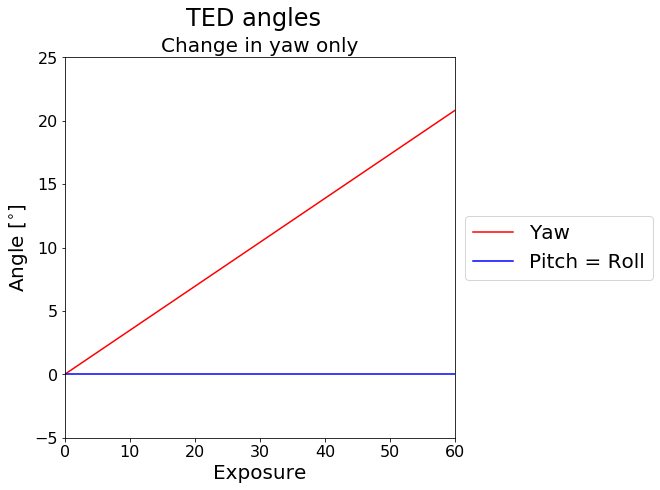

In [5]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, changeYaw / 3600, "r", label="Yaw")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Pitch = Roll")

plt.suptitle("TED angles", fontsize = 24)
plt.title("Change in yaw only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-5, 25])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Yaw
500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
1500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
2500


Error: SimfFile.getStarCoordinates(): Exposure000057 not in hdf5 file
3500


Error: SimfFile.getStarCoordinates(): Exposure000057 not in hdf5 file


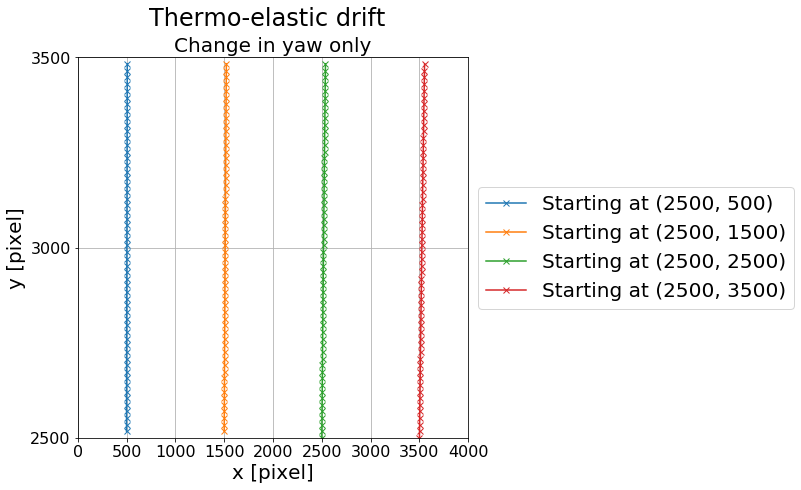

In [6]:
sim["Telescope/DriftFileName"] = driftFilenameYaw2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

delta = 2500

dimColumn = 100
dimRow = 1000

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Yaw")

for position in np.arange(500, 4500, 1000):
    
    print(position)
    
    label = "Starting at (" + str(delta) + ", " + str(position) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([delta]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = delta
    sim["SubField/ZeroPointColumn"] = position
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns + position, rows + delta, marker="x", label=label)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in yaw only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

ax.set_xticks(np.arange(0, 5000, 500))
ax.set_yticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.xlim([0, 4000])
plt.ylim([delta, delta + dimRow])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Change in pitch only (exaggerated)

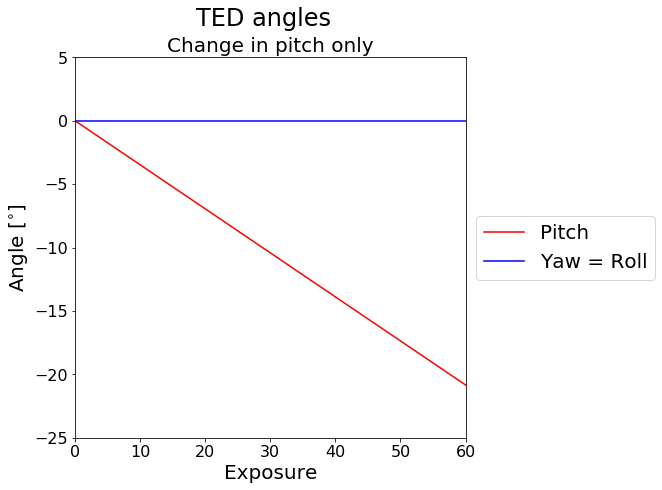

In [7]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, changePitch / 3600, "r", label="Pitch")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Yaw = Roll")

plt.suptitle("TED angles", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-25, 5])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Pitch
500


Error: SimfFile.getStarCoordinates(): Exposure000057 not in hdf5 file
1500


Error: SimfFile.getStarCoordinates(): Exposure000057 not in hdf5 file
2500


Error: SimfFile.getStarCoordinates(): Exposure000057 not in hdf5 file
3500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file


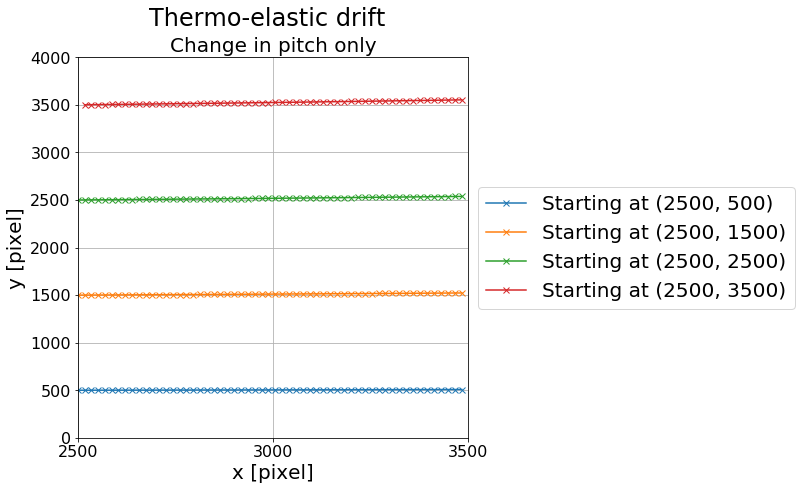

In [8]:
sim["Telescope/DriftFileName"] = driftFilenamePitch2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

delta = 2500

dimColumn = 1000
dimRow = 100

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Pitch")

for position in np.arange(500, 4500, 1000):
    
    print(position)
    
    label = "Starting at (" + str(delta) + ", " + str(position) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([delta]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = position
    sim["SubField/ZeroPointColumn"] = delta
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns + delta, rows + position, marker="x", label=label)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

ax.set_yticks(np.arange(0, 5000, 500))
ax.set_xticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.ylim([0, 4000])
plt.xlim([delta, delta + dimColumn])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Change in roll only (exaggerated)

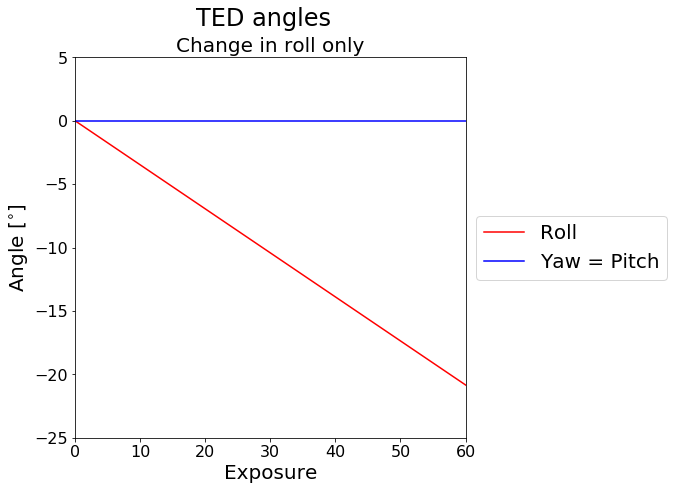

In [9]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, changeRoll / 3600, "r", label="Roll")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Yaw = Pitch")

plt.suptitle("TED angles", fontsize = 24)
plt.title("Change in roll only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-25, 5])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Pitch
10


Error: SimfFile.getStarCoordinates(): Exposure000499 not in hdf5 file
20


Error: SimfFile.getStarCoordinates(): Exposure000499 not in hdf5 file
30


Error: SimfFile.getStarCoordinates(): Exposure000499 not in hdf5 file
40




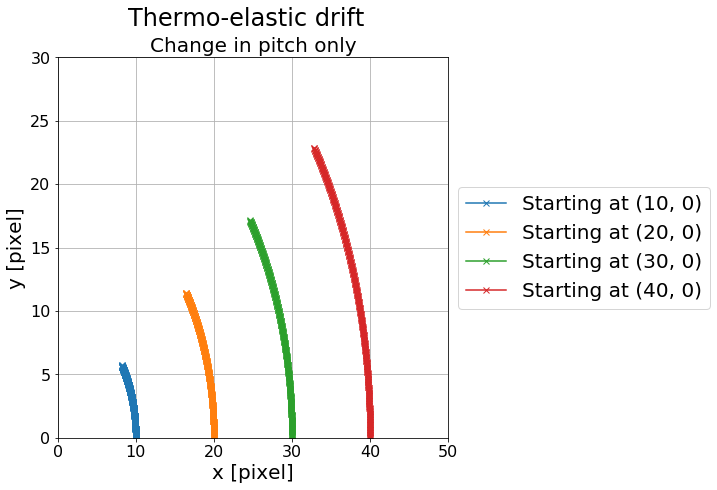

In [10]:
sim["Telescope/DriftFileName"] = driftFilenameRoll2

numExposures = 500
sim["ObservingParameters/NumExposures"] = numExposures

delta = 0

dimColumn = 50
dimRow = 50

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Pitch")

for position in np.arange(10, 50, 10):
    
    print(position)
    
    label = "Starting at (" + str(position) + ", " + str(delta) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([delta]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = 0
    sim["SubField/ZeroPointColumn"] = 0
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns, rows, marker="x", label=label)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

# ax.set_yticks(np.arange(0, 5000, 500))
# ax.set_xticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.ylim([0, 30])
plt.xlim([delta, delta + 50])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Auto-generated TED

In [11]:
sim["Telescope/UseDriftFromFile"] = "no"

rmsYaw = 2.0
rmsPitch = 3.0
rmsRoll = 5.0

sim["Telescope/DriftYawRms"] = rmsYaw
sim["Telescope/DriftPitchRms"] = rmsPitch
sim["Telescope/DriftRollRms"] = rmsRoll

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

sim["ObservingParameters/CycleTime"] = 25

print("Done")


2020-05-19 19:21:45 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-19 19:21:45 WARNING Camera: No star positions to write to HDF5 file.

Done


In [12]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TED.hdf5", 'r')

yaw = h5.h5get(hfile, ["Telescope", "TelescopeYaw"], verbose = True)
pitch = h5.h5get(hfile, ["Telescope", "TelescopePitch"], verbose = True)
roll = h5.h5get(hfile, ["Telescope", "TelescopeRoll"], verbose = True)

selection strings: ['Telescope', 'TelescopeYaw']
matching items:
    Dataset         /Telescope/TelescopeYaw
selection strings: ['Telescope', 'TelescopePitch']
matching items:
    Dataset         /Telescope/TelescopePitch
selection strings: ['Telescope', 'TelescopeRoll']
matching items:
    Dataset         /Telescope/TelescopeRoll


In [13]:
timestep = sim["ObservingParameters/CycleTime"]
timescale = sim["Telescope/DriftTimeScale"]

ratio = timestep / timescale

In [14]:
yawPrevMult = yaw * math.exp(-ratio)
pitchPrevMult = pitch * math.exp(-ratio)
rollPrevMult = roll * math.exp(-ratio)

In [15]:
deltaYaw = yaw[1:] - yawPrevMult[:-1]
deltaPitch = pitch[1:] - pitchPrevMult[:-1]
deltaRoll = roll[1:] - rollPrevMult[:-1]

1.2714357555006681


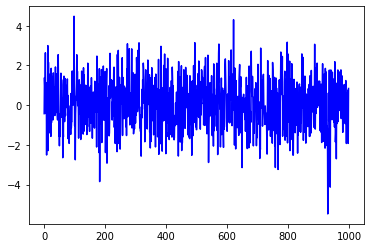

In [16]:
plt.plot(deltaYaw / math.sqrt(ratio), "b")

print(math.sqrt(np.sum(np.power(deltaYaw / math.sqrt(ratio), 2)) / len(deltaYaw)))

1.8513021833464405


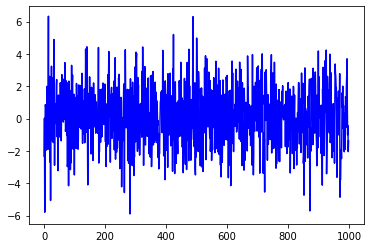

In [17]:
plt.plot(deltaPitch / math.sqrt(ratio), "b")

print(math.sqrt(np.sum(np.power(deltaPitch / math.sqrt(ratio), 2)) / len(deltaPitch)))

3.220912010666108


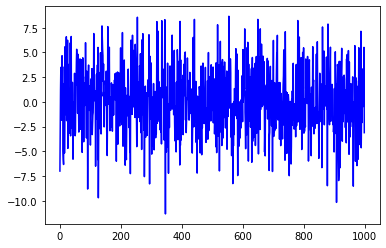

In [18]:
plt.plot(deltaRoll / math.sqrt(ratio), "b")

print(math.sqrt(np.sum(np.power(deltaRoll / math.sqrt(ratio), 2)) / len(deltaRoll)))

0.6349509539667908
0.6161956292081007
0.6436528044054346


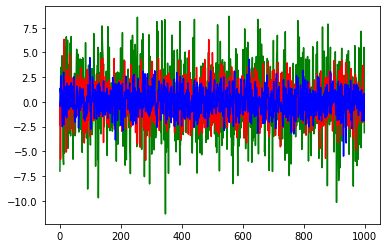

In [19]:
plt.plot(deltaRoll / math.sqrt(ratio), "g")
plt.plot(deltaPitch / math.sqrt(ratio), "r")
plt.plot(deltaYaw / math.sqrt(ratio), "b")

print(np.std(deltaYaw / math.sqrt(ratio)) / rmsYaw)
print(np.std(deltaPitch / math.sqrt(ratio)) / rmsPitch)
print(np.std(deltaRoll / math.sqrt(ratio)) / rmsRoll)

In [20]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TED.hdf5", 'r')
time = h5.h5get(hfile, ["ACS", "Time"], verbose = True)

selection strings: ['ACS', 'Time']
matching items:
    Dataset         /ACS/Time


In [21]:
print("Timescale for TED:", sim["Telescope/DriftTimeScale"], "s")

Timescale for TED: 86400.0 s


In [22]:
def rms(data):
    
    return np.sqrt(np.mean(np.square(data)))

In [23]:
deltaYaw = (yaw[1:] - math.exp(-timestep / timescale) * yaw[:-1]) / math.sqrt(timestep / timescale)
deltaPitch = (pitch[1:] - math.exp(-timestep / timescale) * pitch[:-1]) / math.sqrt(timestep / timescale)
deltaRoll = (roll[1:] - math.exp(-timestep / timescale) * roll[:-1]) / math.sqrt(timestep / timescale)

# plt.plot(deltaYaw)
print(np.std(deltaYaw))
# print(rms(deltaYaw))

print(np.std(deltaPitch))
# print(rms(deltaPitch))

print(np.std(deltaRoll))
# print(rms(deltaRoll))

1.2699019079335816
1.848586887624302
3.218264022027173


In [24]:
print(np.std(np.diff(yaw, n=1)))
print(np.std(np.diff(pitch, n=1)))
print(np.std(np.diff(roll, n=1)))

# print(rms(np.diff(yaw, n=1)))
# print(rms(pitch))
# print(rms(roll))

0.02160844228877356
0.03145386287757706
0.054758010917585635


### Yaw

Text(0, 0.5, 'Yaw [degrees]')

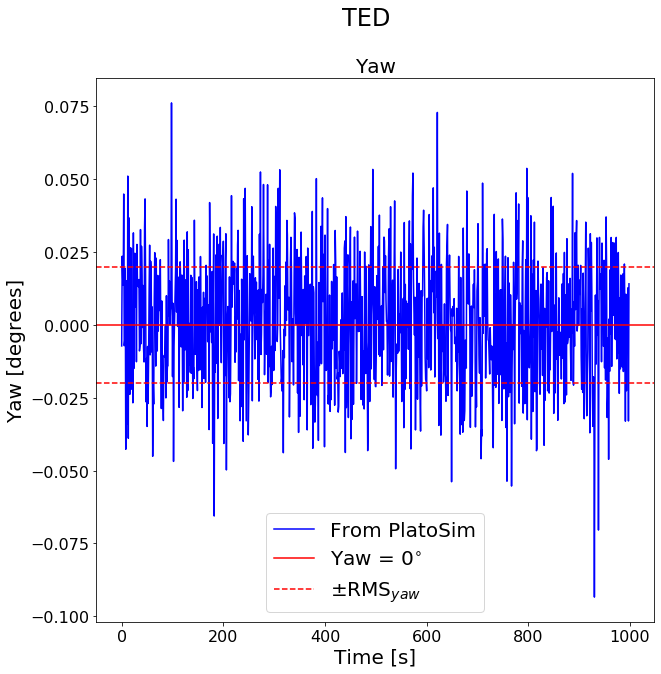

In [25]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(np.diff(yaw, n=1), "b", label = "From PlatoSim")
# plt.plot(time, yaw, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Yaw = 0$^{\circ}$")
plt.axhline(y = 0 - rmsYaw/100, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{yaw}$")
plt.axhline(y = 0 + rmsYaw/100, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Yaw [degrees]", fontsize = 20)

[ 7.76295355e+02+0.00000000e+00j -1.25260287e+02+1.29576095e+02j
 -2.39784490e+01+4.40665471e+01j  4.22546192e+01+2.65389549e+01j
 -4.18605096e+01+1.81193415e+01j  1.61921079e+00+2.67496206e+01j
  2.68660598e+00+1.72245585e+01j -9.85578044e+00+1.92874139e+01j
 -3.40351949e+00+4.40485335e+00j -3.64757592e+00+9.49720686e+00j
 -2.34336874e+00+3.27730622e+00j  5.69279859e+00+1.42123611e+01j
 -6.69115707e+00+2.04646969e+01j -2.22513483e+00+1.60733375e+01j
  1.14680204e+00+1.56916134e+01j  2.31289614e+00+1.50462369e+01j
 -4.55467341e+00+1.37858762e+01j  3.51244708e+00+1.04711501e+01j
 -8.12842358e+00+2.94320688e+00j  1.38387368e+00+3.06011436e+00j
 -2.90170910e+00+5.27038749e+00j  1.85243338e+00+8.79861445e+00j
 -6.20907415e-03+8.22880702e+00j -1.17022519e+00+4.57955354e+00j
  2.61455955e+00+1.01865615e+01j -5.00835224e-01+6.41266473e+00j
  1.81025216e+00+2.63719304e+00j -1.92564774e+00+5.03906159e+00j
 -1.70146125e+00+1.14607710e+00j  2.64540861e+00+5.84254717e+00j
 -2.53165455e+00+3.654320

Text(0, 0.5, 'PSD')

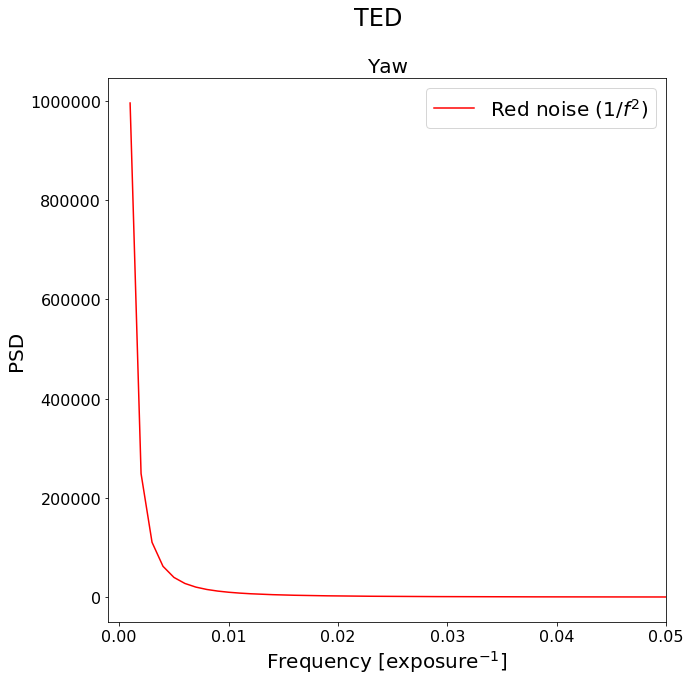

In [26]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(yaw)     # Fast Fourier transform of the yaw time series
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

# plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")

print(xF)



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.05])
# plt.ylim([0, 10000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

499


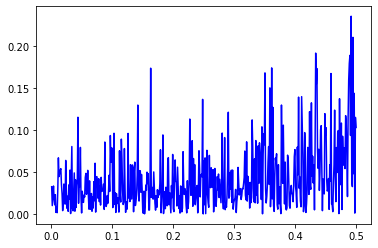

In [27]:
plt.plot(fr[1:], (abs(xF[1:])**2) / redNoise, "b", label = "From PlatoSim")
abs(xF[1:])**2
print(len(redNoise))

In [28]:
print(xF**2)

[ 6.02634477e+05+0.00000000e+00j -1.09982505e+03-3.24614778e+04j
 -1.36689455e+03-2.11329491e+03j  1.08113672e+03+2.24278686e+03j
  1.42399173e+03-1.51696974e+03j -7.12920360e+02+8.66265484e+01j
 -2.89467564e+02+9.25512039e+01j -2.74867925e+02-3.80185032e+02j
 -7.81878814e+00-2.99840085e+01j -7.68921281e+01-6.92835660e+01j
 -5.24935904e+00-1.53598739e+01j -1.69583253e+02+1.61816219e+02j
 -3.74032236e+02-2.73865002e+02j -2.53400953e+02-7.15306862e+01j
 -2.44911575e+02+3.59903483e+01j -2.21039756e+02+6.96007664e+01j
 -1.69305332e+02-1.25580327e+02j -9.73077009e+01+7.35587216e+01j
  5.74088032e+01-4.78472645e+01j -7.44919351e+00+8.46962343e+00j
 -1.93570686e+01-3.05862627e+01j -7.39841068e+01+3.25976942e+01j
 -6.77132264e+01-1.02186546e-01j -1.96028836e+01-1.07182178e+01j
 -9.69301137e+01+5.32667434e+01j -4.08714330e+01-6.42337676e+00j
 -3.67777421e+00+9.54796880e+00j -2.16840225e+01-1.94069151e+01j
  1.58147765e+00-3.90001155e+00j -2.71371708e+01+3.09118492e+01j
 -6.94478119e+00-1.850295

### Pitch

/Users/sara/anaconda3/envs/platosim/lib/python3.6/site-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  # Remove the CWD from sys.path while we load stuff.


Text(0, 0.5, 'Pitch [degrees]')

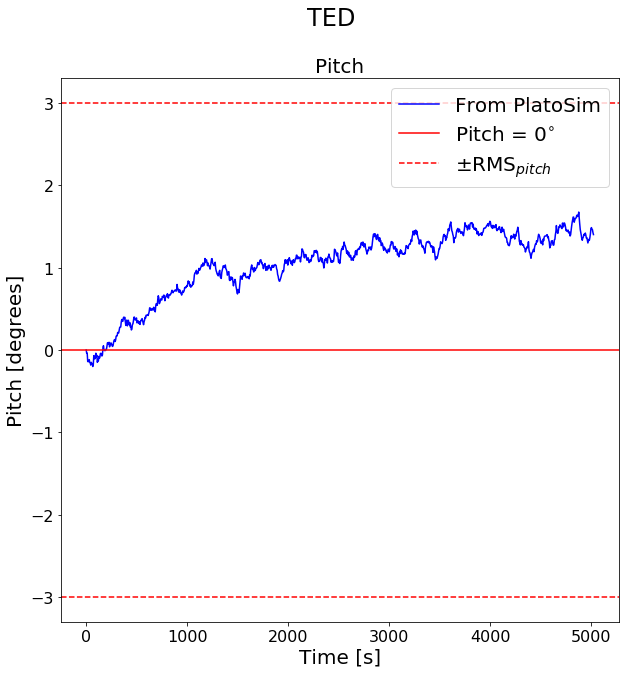

In [29]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(time, pitch, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Pitch = 0$^{\circ}$")
plt.axhline(y = 0 - rmsPitch, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{pitch}$")
plt.axhline(y = 0 + rmsPitch, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Pitch [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

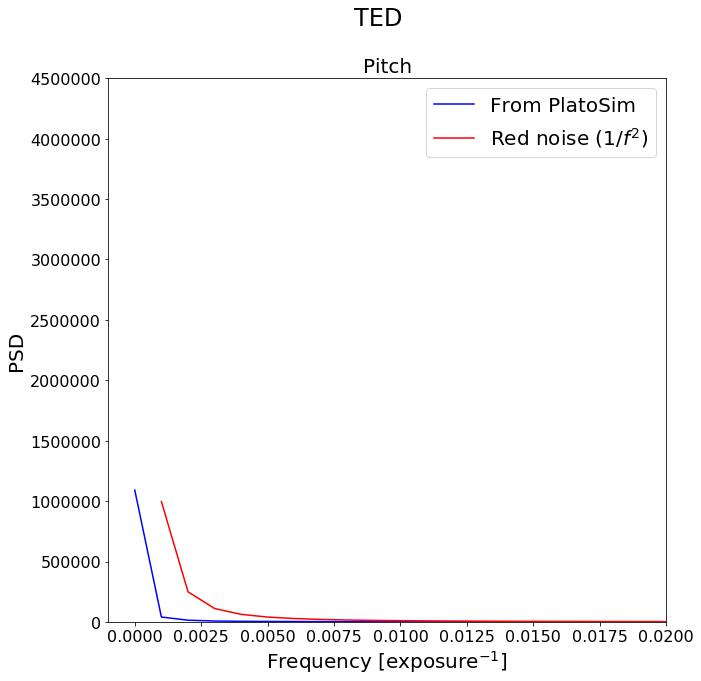

In [30]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(pitch)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.02])
plt.ylim([0, 4500000])

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Roll

Text(0, 0.5, 'Roll [degrees]')

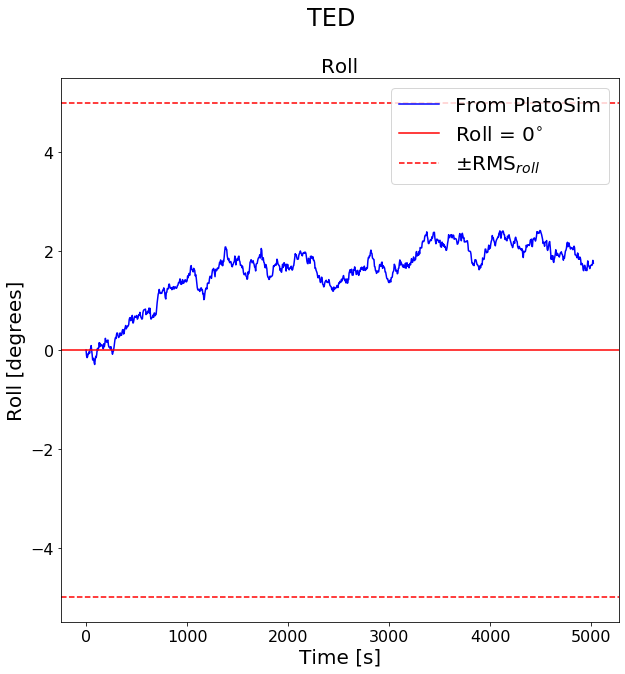

In [31]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(time, roll, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Roll = 0$^{\circ}$")
plt.axhline(y = 0 - rmsRoll, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{roll}$")
plt.axhline(y = 0 + rmsRoll, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Roll [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

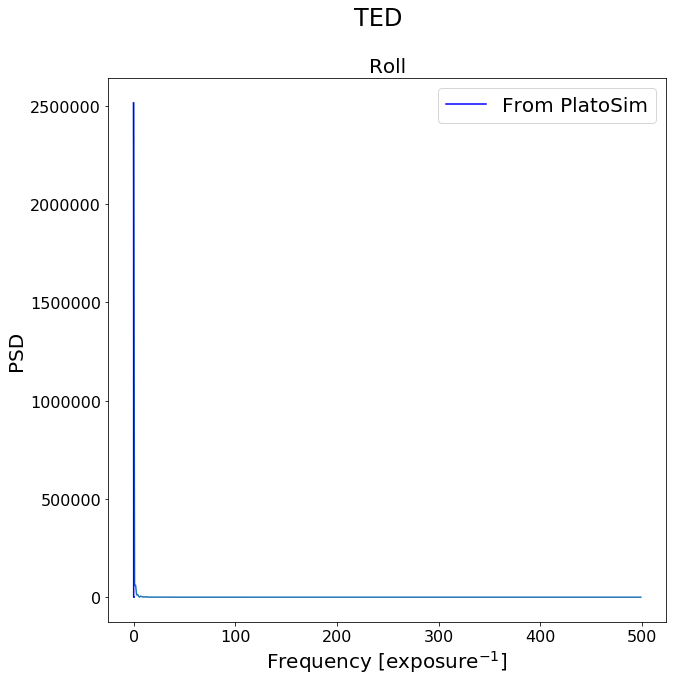

In [32]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(roll)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))
plt.plot(abs(xF)**2)

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

# plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

# plt.xlim([-0.001, 0.02])
# plt.ylim([0, 15000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

In [33]:
# def rednoiseModel(freq, tau, sigma):

#     """
#     PURPOSE: compute the mean power spectral density (PSD) corresponding to the red noise
#              time series that is generated by a red noise model (random walk).

#     INPUT: freq:       frequency points of the PSD  [microHz | mHz | Hz]
#            tau:  time scale of the red noise
#            sigma:   variation scale

#     OUTPUT: psd:  power spectral density   [ppm^2/microHz | ppm^2/microHz | ppm^2/microHz]
#     """

#     psd = sigma * sigma * tau / (1.0 + (2.0*np.pi*freq*tau)**2)
    
#     return psd

In [34]:
# redNoise = rednoiseModel(fr,  sim["Telescope/DriftTimeScale"] / 25., rmsYaw)